## Bank marketing and deposit prediction

For this project I will apply different models to predict which bank customers that will make a  deposit from being approached by a marketing campaign. This provides valuable knowledge for which customers should be targeted and how targeting can be done effectively.

The dataset is retrived from Kaggle can be found here: https://www.kaggle.com/datasets/nalisha/bank-marketing-dataset-for-deposit-prediction. 

# Libraries

In [138]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

We begin by loading in the data proceed to visually inspect the data to see which methods might be suitable for this case. Also some preprocessing is done tot enable analysis.

From the information we have about the data the interpretation of all variables is not clear. Therefore i chose to only include variables which we are able to interpret as I want the model to balance accuracy with interpretability. 

Another important decision is wether the variable duration should be kept or not. It refers to the duration of the call when the customer was contacted. Including it will probably raise performance in therms of accuracy, sensitivity and specificity. But I still argue it should not be included since it is information not available beforehand and thus does not help. When classifying a customer as probable to make a deposit which affects if we call or not the information of call duration will not be available. Therefore it is not included in the model.

# Exploratory data analysis 

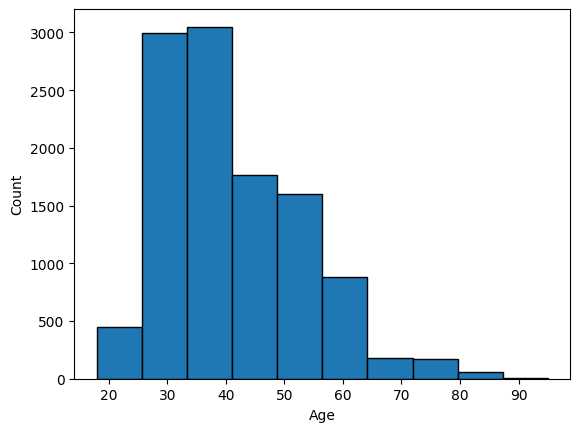

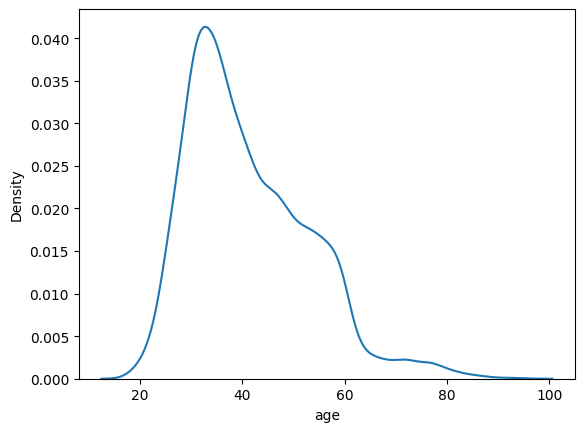

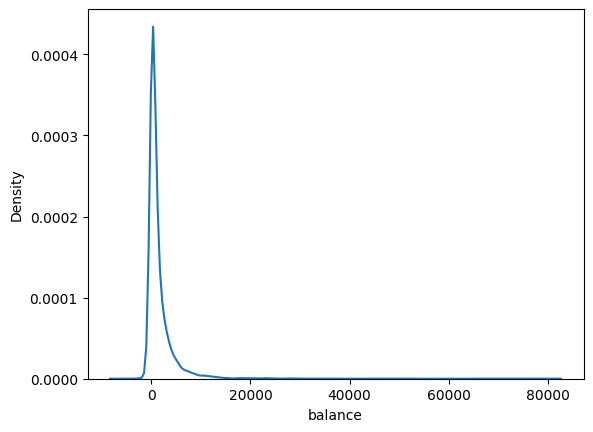

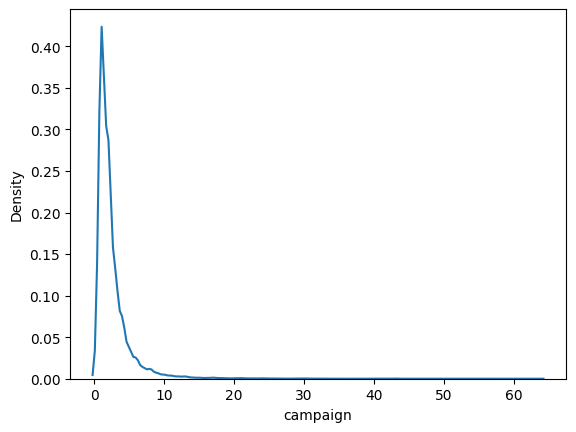

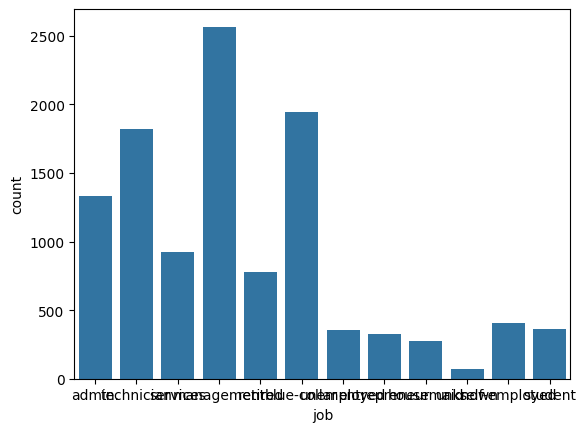

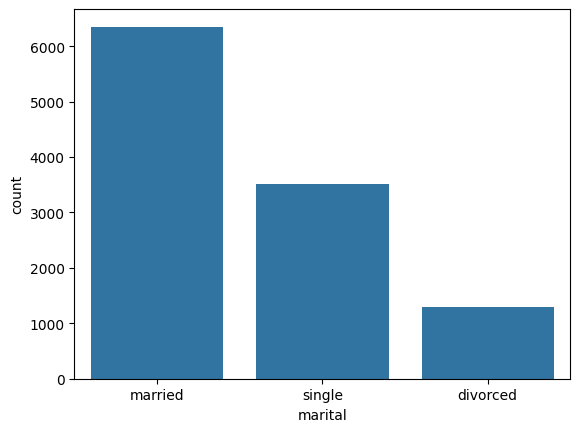

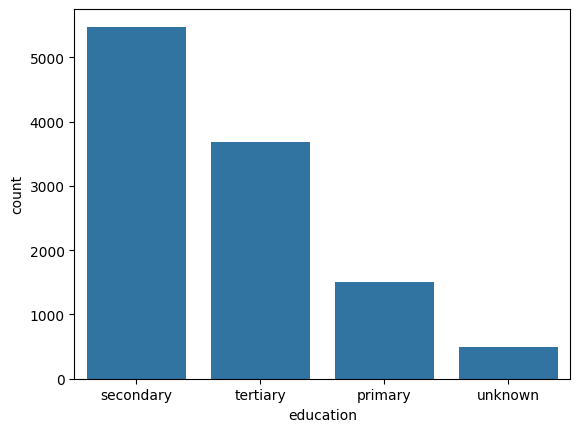

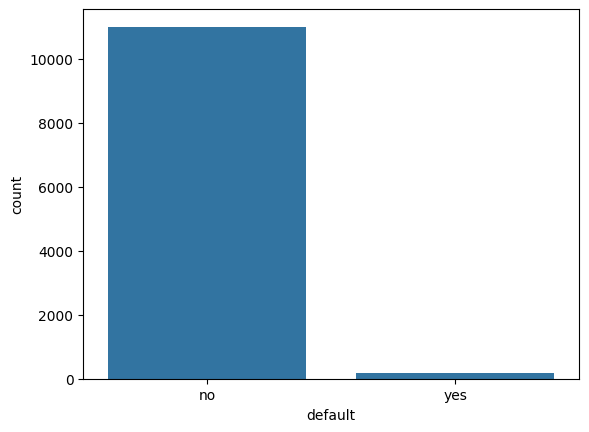

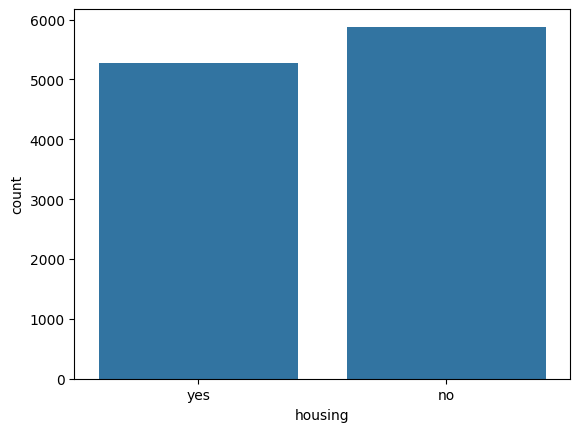

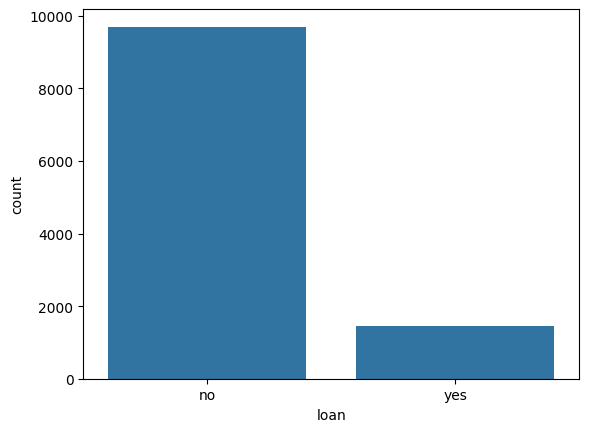

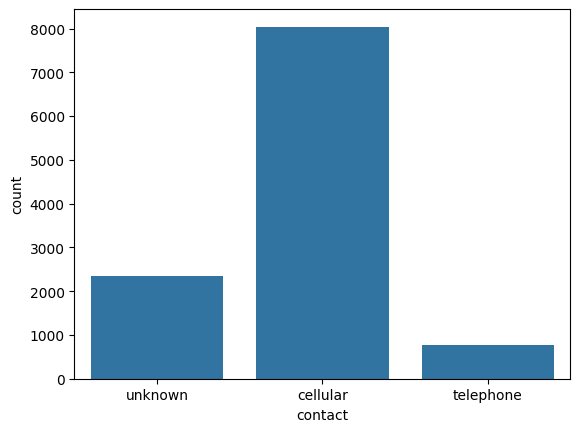

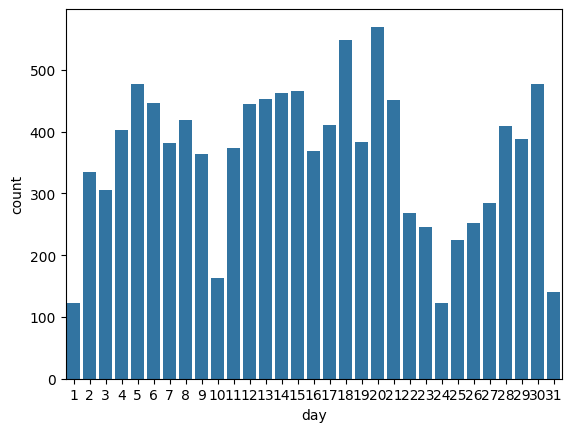

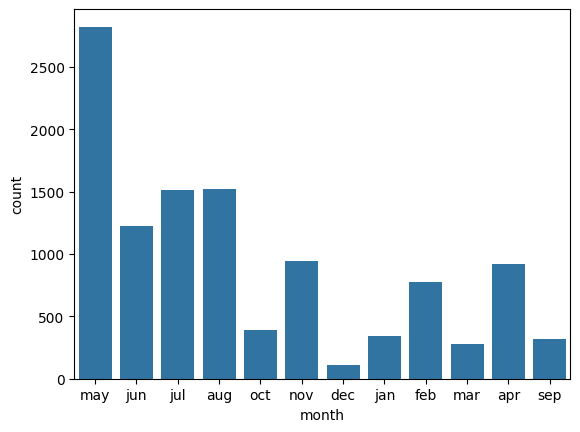

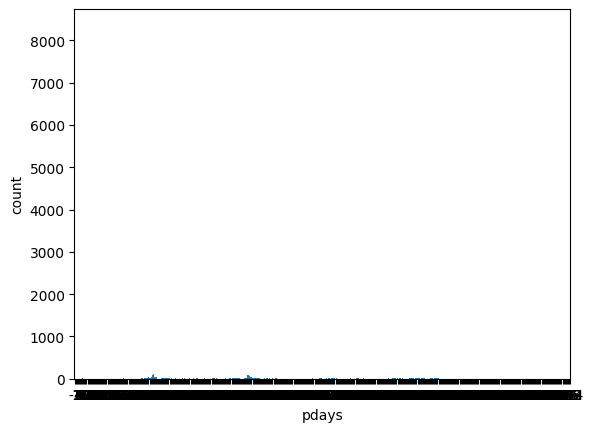

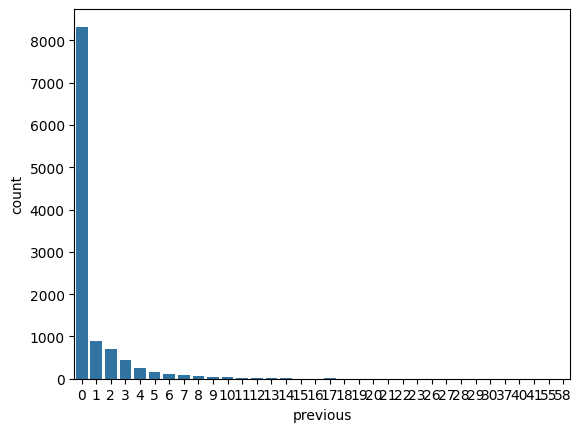

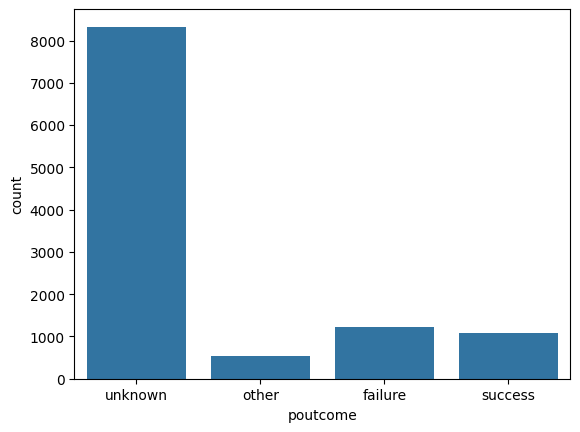

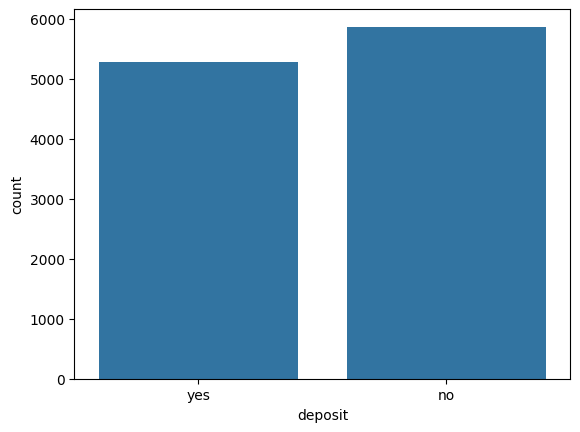

In [139]:
#The dataset contains ~11 000 obs

continous_columns = ['age', 'balance', 'campaign']

bank_data = pd.read_csv('bank.csv')

plt.hist(bank_data['age'], bins= 10, edgecolor = 'black')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

for col in continous_columns:
    sns.kdeplot(x = col, data = bank_data)
    plt.show()

other_cols = bank_data.drop(continous_columns, axis= 1)
other_cols = other_cols.drop("duration", axis = 1)

for col in other_cols:
    sns.countplot(x = col, data= bank_data)
    plt.show()


As we can see some preprocessing is needed in order to make analysis possible. Especially encoding the categorical variables and standardizing the continous variables. The variable Pdays needs to be recoded into to separate variables, one continous and one binary.

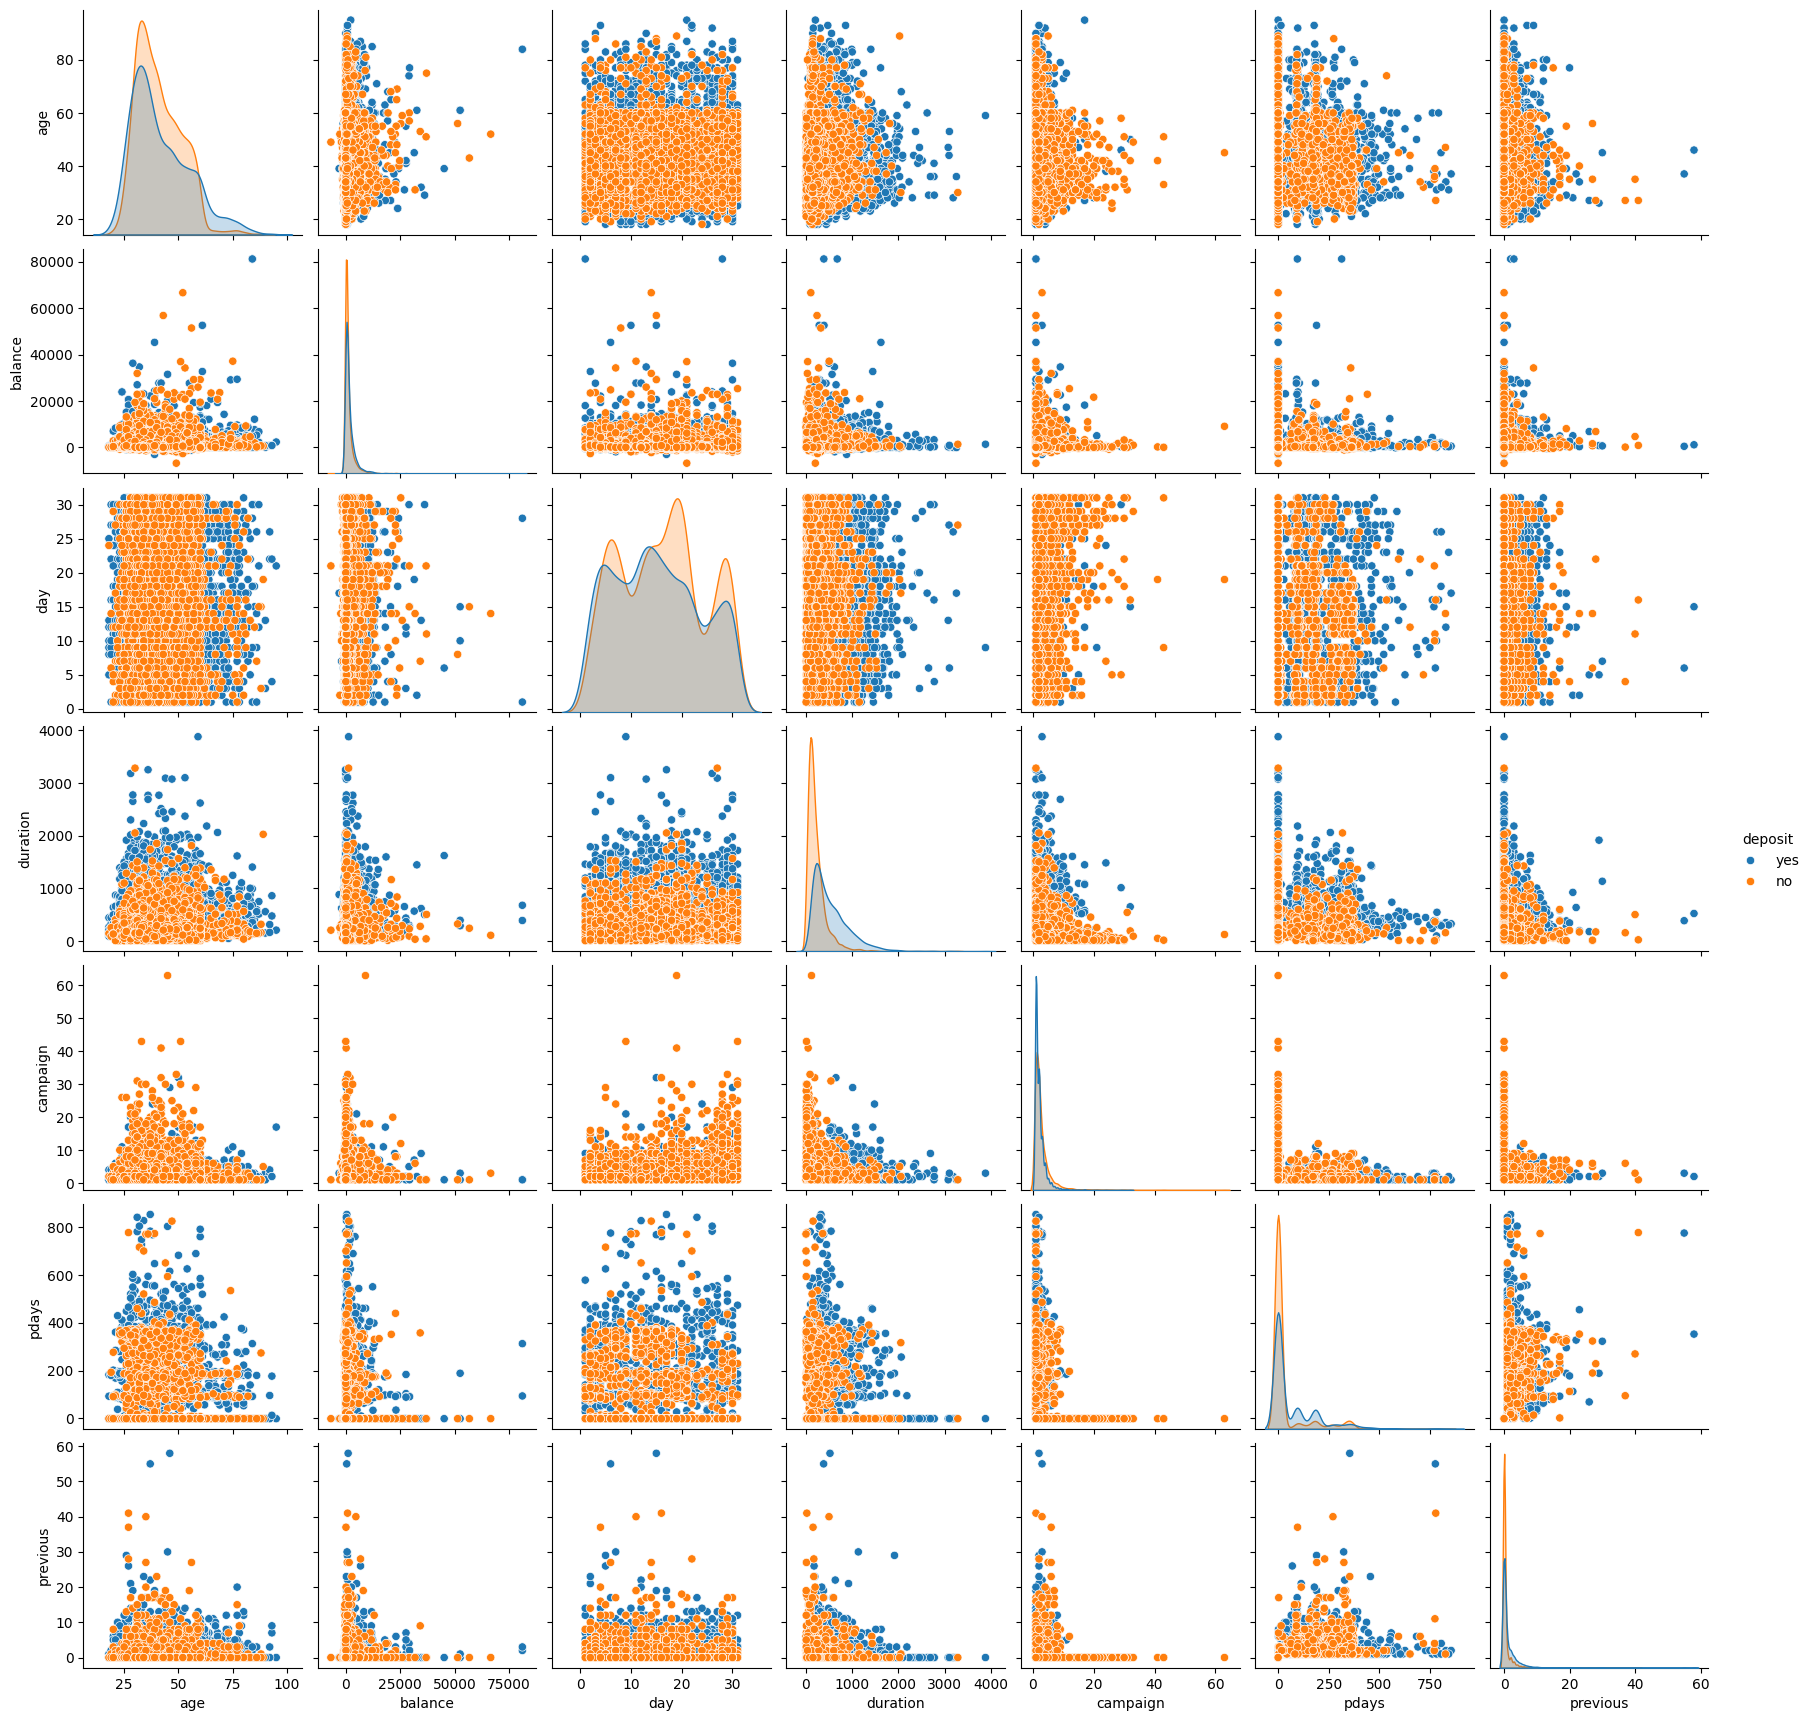

In [140]:
sns.pairplot(bank_data, hue = 'deposit')
plt.show()

From here we see that no single variable alone is able to able to separate the classes very well. This is an indication that a linear classifier will not be sufficient for good performance. Therefore the random forest, XG boost and SVC with a non-linear kernel should perform better than logistic regression for this data.

# Data preprocessing

In [141]:
encoder = OneHotEncoder(sparse_output=False)

string_columns = bank_data.select_dtypes(include='object').columns
bank_data[string_columns] = bank_data[string_columns].apply(lambda x: x.str.strip().str.title())


encoded_data_job = encoder.fit_transform(bank_data[['job']])
encoded_df_job = pd.DataFrame(encoded_data_job, columns= encoder.get_feature_names_out())


encoded_data_marital = encoder.fit_transform(bank_data[['marital']])
encoded_df_marital = pd.DataFrame(encoded_data_marital, columns= encoder.get_feature_names_out())
#print(encoded_df_marital)

encoded_data_education = encoder.fit_transform(bank_data[['education']])
encoded_df_education = pd.DataFrame(encoded_data_education, columns=encoder.get_feature_names_out())
#print(encoded_df_education)

le = LabelEncoder()

yes_no_columns = ['default', 'housing', 'loan', 'deposit']

for col in yes_no_columns:
    bank_data[col] = le.fit_transform(bank_data[col])

encoded_data_contact = encoder.fit_transform(bank_data[['contact']])
encoded_df_contact = pd.DataFrame(encoded_data_contact, columns=encoder.get_feature_names_out())

bank_data['time_of_month'] = pd.cut(bank_data['day'],
                                    bins= [0,10,20,31],
                                    labels = ['Start', 'Mid', 'End']
                                    )

month_map = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4,
    'May': 5, 'Jun': 6, 'Jul': 7, 'Aug': 8,
    'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}

bank_data['month'] = bank_data['month'].map(month_map)

bank_data['time_of_year'] = pd.cut(bank_data['month'],
                                   bins= [0,3,6,9,12],
                                   labels = ['Q1', 'Q2', 'Q3', 'Q4']
                                   )


encoded_data_time_of_mnth = encoder.fit_transform(bank_data[['time_of_month']])
encoded_df_time_of_mnth = pd.DataFrame(encoded_data_time_of_mnth, columns=encoder.get_feature_names_out())

encoded_data_time_of_year = encoder.fit_transform(bank_data[['time_of_year']])
encoded_df_time_of_year = pd.DataFrame(encoded_data_time_of_year, columns=encoder.get_feature_names_out())

bank_data_combined = bank_data.join(encoded_df_job)
bank_data_combined = bank_data_combined.join(encoded_df_education)
bank_data_combined = bank_data_combined.join(encoded_df_marital)
bank_data_combined = bank_data_combined.join(encoded_df_time_of_mnth)
bank_data_combined = bank_data_combined.join(encoded_df_time_of_year)

old_cols = ['job', 'marital', 'education', 'day', 'poutcome', 'contact', 'time_of_year', 'time_of_month', 'month', 'duration']

for col in old_cols:
    bank_data_combined = bank_data_combined.drop(col, axis=1)

bank_data['previously_contacted'] = (bank_data['pdays'] != -1).astype(int)
bank_data['pdays'] = bank_data['pdays'].replace(-1, 0)


In [142]:
#Standardization

continous_columns = ['age', 'balance', 'campaign', 'pdays']

standadizing_preprocessing = ColumnTransformer(
    transformers=[('num', StandardScaler(), continous_columns)],
    remainder= 'passthrough'

)

X = standadizing_preprocessing.fit_transform(bank_data_combined.drop('deposit', axis = 1))
y = bank_data_combined['deposit']


# SVC

In [143]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=30, stratify= y
)


param_grid = {
    'C': [1,3,5],
    'gamma': [0.1, 1,5,10],
    'kernel': ['rbf']
}

grid = RandomizedSearchCV(
    SVC(probability= True), 
    param_grid,
    n_iter= 20,
    refit=True, 
    verbose=2, 
    cv=3, 
    n_jobs=-1,
    random_state= 47
)


grid.fit(X_train, y_train)


print(f"Best Parameters: {grid.best_params_}")
print(f"Best Score: {grid.best_score_:.4f}")


grid_predictions = grid.predict(X_test)

pred_prob_SVC = grid.predict_proba(X_test)[:,1]

fpr_svc, tpr_svc, threshold_svc = roc_curve(y_test, pred_prob_SVC)

auc_svc = auc(fpr_svc, tpr_svc)

C:\Users\hugoe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 12 is smaller than n_iter=20. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Parameters: {'kernel': 'rbf', 'gamma': 0.1, 'C': 1}
Best Score: 0.6915


In [144]:
print(confusion_matrix(y_test, grid_predictions))

print(classification_report(y_test, grid_predictions))

[[943 232]
 [478 580]]
              precision    recall  f1-score   support

           0       0.66      0.80      0.73      1175
           1       0.71      0.55      0.62      1058

    accuracy                           0.68      2233
   macro avg       0.69      0.68      0.67      2233
weighted avg       0.69      0.68      0.68      2233



# Random Forest

In [145]:

pipe = Pipeline(
    steps=[('classifier',RandomForestClassifier())]
)

param_grid = ({
    "classifier__n_estimators":[10,50,100,500],
    "classifier__max_depth":[10,15,20,None],
    "classifier__min_samples_split":[2,5,10],
    "classifier__min_samples_leaf":[1,4,7]
})

param_search = GridSearchCV(pipe, param_grid, cv=5, n_jobs=-1, verbose= 2)

param_search.fit(X_train, y_train)

print(f'Best parameters: {param_search.best_params_}')

pred_y = param_search.predict(X_test)

print("Model Accuracy:", accuracy_score(y_test, pred_y))
print(classification_report(y_test, pred_y))

pred_prob_rf = param_search.predict_proba(X_test)[:,1]

fpr_rf, tpr_rf, threshold_rf = roc_curve(y_test, pred_prob_rf)

auc_rf = auc(fpr_rf, tpr_rf)


Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best parameters: {'classifier__max_depth': 20, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 500}
Model Accuracy: 0.6918943125839677
              precision    recall  f1-score   support

           0       0.68      0.79      0.73      1175
           1       0.72      0.58      0.64      1058

    accuracy                           0.69      2233
   macro avg       0.70      0.69      0.69      2233
weighted avg       0.70      0.69      0.69      2233



# XG BOOST


In [146]:
pipe = Pipeline(
    steps =[('classifier', XGBClassifier())]
)

param_grid_boost = ({
    "classifier__n_estimators":[20,50,100],
    "classifier__learning_rate": [0.01,0.1,0.3,0.5],
    "classifier__max_depth": [2,3,4,5,7],
    "classifier__subsample": [0.5,0.7,1],
    "classifier__colsample_bytree": [0.7, 1.0]

})

param_search_boost = GridSearchCV(pipe, param_grid_boost, cv=5, n_jobs=-1, verbose= 2)

param_search_boost.fit(X_train, y_train)

print(f'Best params: {param_search_boost.best_params_}')

pred_y_boost = param_search_boost.predict(X_test)

print(f'Accuracy: {accuracy_score(y_test, pred_y_boost)}')
print(f'Confusion matrix: {classification_report(y_test, pred_y_boost)}')

pred_prob_xg = param_search_boost.predict_proba(X_test)[:,1]

fpr_xg, tpr_xg, threshold_xg = roc_curve(y_test, pred_prob_xg)

auc_xg = auc(fpr_xg, tpr_xg)

Fitting 5 folds for each of 360 candidates, totalling 1800 fits
Best params: {'classifier__colsample_bytree': 0.7, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 100, 'classifier__subsample': 0.7}
Accuracy: 0.6932377966860725
Confusion matrix:               precision    recall  f1-score   support

           0       0.67      0.81      0.74      1175
           1       0.73      0.56      0.63      1058

    accuracy                           0.69      2233
   macro avg       0.70      0.69      0.69      2233
weighted avg       0.70      0.69      0.69      2233



# Logistic regression

In [147]:
log_model = LogisticRegression(solver='lbfgs', max_iter=100000)
log_model.fit(X_train, y_train)

yes_prob = log_model.predict_proba(X_test)[:, 1]
y_pred_log = (yes_prob >= 0.50).astype(int)

print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

fpr, tpr, _ = roc_curve(y_test, yes_prob)
roc_auc = auc(fpr, tpr)

[[831 344]
 [441 617]]
              precision    recall  f1-score   support

           0       0.65      0.71      0.68      1175
           1       0.64      0.58      0.61      1058

    accuracy                           0.65      2233
   macro avg       0.65      0.65      0.65      2233
weighted avg       0.65      0.65      0.65      2233



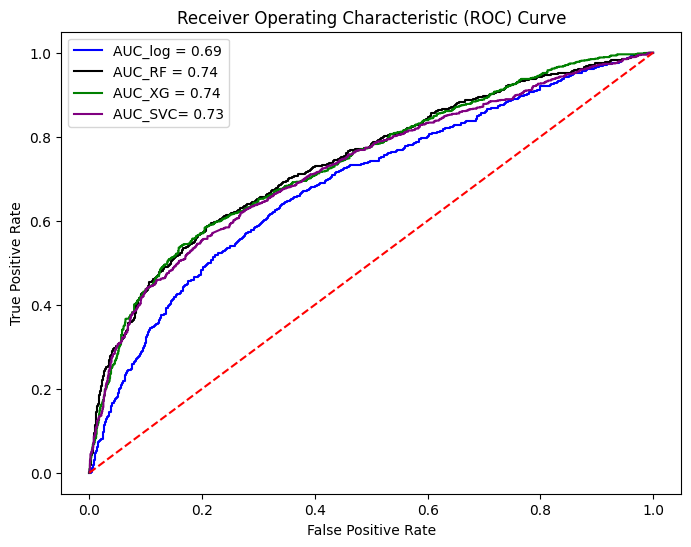

In [148]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'AUC_log = {roc_auc:.2f}')
plt.plot(fpr_rf, tpr_rf, color ='black', label=f'AUC_RF = {auc_rf:.2f}')
plt.plot(fpr_xg, tpr_xg, color ='green', label=f'AUC_XG = {auc_xg:.2f}')
plt.plot(fpr_svc, tpr_svc, color = 'purple', label=f'AUC_SVC= {auc_svc:.2f}')
plt.plot([0, 1], [0, 1], color='red', linestyle='--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

As we can see the performance of RF, XGboost and SCV is similar whilst the logistic regression model is performing worse. In order to better predict which customers to contact more data (either more data points or more variables) would be needed. The models can from the available data not fully capture the relationship between inputs and output.

There is some non-linearity in the relationship which is captured by the RF model and not by the logistic rgeression model which is the reason for the 5% difference in AUC between these two models. This may also be caused by some overfitting in the logistic regression which could be handled by regularization. However this is not pursued since the models which are able to capture non linear relationships should perform better still. 

# Insights

The practical gain from this analysis is that it enables on which customers to call which not to call. By ranking all customers based on the probability (produced by the models) of making a deposit the bank can decide how many of all the customers which should be contacted. The AUC value explicitly tells us how likely the model is to correctly assign higher probabilites to deposit compared to non depositing customers. The value of 0.74 from RF and XG boost is not perfect but alot better than just calling customers based on a random guess, in such a case the AUC is 0.5. As mentioned above, to increase performance more data/ information would be needed.

The probability threshhold for contact/ no contact based on what maximizes the gain of the bank. By having information about the average gain from a deposit and the cost per customer contacted this could be optimized. 